In [80]:
import numpy as np
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from matplotlib import colors
from PIL import Image
import re
import ot

In [81]:
output_folder = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/distortion_maps")
desired_resolution = (64, 64)

In [82]:
def load_gray(path: Path, resolution: tuple[int, int] | None = None) -> np.ndarray:
    with Image.open(path) as img:
        if resolution is not None:
            target_height, target_width = resolution
            if img.size != (target_width, target_height):
                img = img.resize((target_width, target_height), resample=Image.BILINEAR)
        return np.asarray(img, dtype=np.float64)

In [83]:
def refine_density_with_adam(
    source_coords_np: np.ndarray,
    source_density_np: np.ndarray,
    target_density_np: np.ndarray,
    *,
    init_field_np: np.ndarray | None = None,
    mid_density_np: np.ndarray | None = None,
    mid_weight: float = 1.0,
    smoothness_weight: float = 0.0,
    magnitude_weight: float = 0.0,
    lr: float = 1e-3,
    max_iters: int = 10_000,
    log_interval: int = 200,
    device: torch.device | None = None,
) -> dict:
    source_coords_np = np.asarray(source_coords_np, dtype=np.float32)
    source_density_np = np.asarray(source_density_np, dtype=np.float32)
    target_density_np = np.asarray(target_density_np, dtype=np.float32)
    height, width, _ = source_coords_np.shape
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    smoothness_weight, magnitude_weight = float(smoothness_weight), float(magnitude_weight)
    print("Using device:", device)

    coords_t = torch.from_numpy(source_coords_np).to(device=device)
    source_mass_t = torch.from_numpy(source_density_np).to(device=device)
    target_mass_t = torch.from_numpy(target_density_np).to(device=device)
    base_field = torch.from_numpy(np.asarray(init_field_np, dtype=np.float32)).to(device=device) if init_field_np is not None else torch.zeros_like(coords_t)
    field = torch.nn.Parameter(base_field.clone())
    optimizer = torch.optim.Adam([field], lr=lr)
    loss_history, primary_loss_history, mid_loss_history, smooth_loss_history, magnitude_loss_history = [], [], [], [], []

    mid_target_t = None
    if mid_density_np is not None:
        mid_density_np = np.asarray(mid_density_np, dtype=np.float32)
        if mid_density_np.shape != (height, width):
            raise ValueError("Intermediate density must match the source grid shape")
        mid_target_t = torch.from_numpy(mid_density_np).to(device=device)

    def push_forward_density(field_tensor: torch.Tensor, scale: float = 1.0) -> torch.Tensor:
        distorted = coords_t + field_tensor * scale
        dest_x = ((distorted[..., 1] + 1.0) * 0.5 * (width - 1)).clamp(0.0, width - 1.0)
        dest_y = ((distorted[..., 0] + 1.0) * 0.5 * (height - 1)).clamp(0.0, height - 1.0)
        x0, y0 = dest_x.floor().long(), dest_y.floor().long()
        x1, y1 = torch.clamp(x0 + 1, max=width - 1), torch.clamp(y0 + 1, max=height - 1)
        wx, wy = dest_x - x0.to(dest_x.dtype), dest_y - y0.to(dest_y.dtype)
        w00, w10, w01, w11 = (1.0 - wx) * (1.0 - wy), wx * (1.0 - wy), (1.0 - wx) * wy, wx * wy
        flat_mass = source_mass_t.reshape(-1)
        expected = torch.zeros_like(flat_mass)
        expected.scatter_add_(0, (y0 * width + x0).reshape(-1), flat_mass * w00.reshape(-1))
        expected.scatter_add_(0, (y0 * width + x1).reshape(-1), flat_mass * w10.reshape(-1))
        expected.scatter_add_(0, (y1 * width + x0).reshape(-1), flat_mass * w01.reshape(-1))
        expected.scatter_add_(0, (y1 * width + x1).reshape(-1), flat_mass * w11.reshape(-1))
        return expected.view(height, width) / expected.sum().clamp_min(1e-12)

    def smoothness_penalty(f: torch.Tensor) -> torch.Tensor:
        return (f[1:, :, :] - f[:-1, :, :]).pow(2).mean() + (f[:, 1:, :] - f[:, :-1, :]).pow(2).mean() if f.shape[0] > 1 and f.shape[1] > 1 else torch.tensor(0.0, device=f.device)

    with torch.no_grad():
        expected_initial_t = push_forward_density(base_field)
        expected_mid_initial = push_forward_density(base_field, scale=0.5).cpu().numpy() if mid_target_t is not None else None
        baseline_loss = float(torch.nn.functional.l1_loss(expected_initial_t, target_mass_t))

    for step in range(int(max_iters)):
        optimizer.zero_grad()
        expected_density_t = push_forward_density(field)
        primary_loss = torch.nn.functional.l1_loss(expected_density_t, target_mass_t)
        total_loss = primary_loss
        mid_loss_value, smooth_loss_value, magnitude_loss_value = 0.0, 0.0, 0.0
        if mid_target_t is not None:
            mid_loss = torch.nn.functional.l1_loss(push_forward_density(field, scale=0.5), mid_target_t)
            total_loss, mid_loss_value = total_loss + mid_weight * mid_loss, float(mid_loss.item())
        if smoothness_weight > 0.0:
            smooth_loss = smoothness_penalty(field)
            total_loss, smooth_loss_value = total_loss + smoothness_weight * smooth_loss, float(smooth_loss.item())
        if magnitude_weight > 0.0:
            magnitude_loss = field.pow(2).sum(dim=-1).mean()
            total_loss, magnitude_loss_value = total_loss + magnitude_weight * magnitude_loss, float(magnitude_loss.item())
        total_loss.backward()
        optimizer.step()
        with torch.no_grad():
            field.data.copy_(torch.clamp(coords_t + field.data, min=-1.0, max=1.0) - coords_t)
        loss_history.append(float(total_loss.item()))
        primary_loss_history.append(float(primary_loss.item()))
        if mid_target_t is not None: mid_loss_history.append(mid_loss_value)
        if smoothness_weight > 0.0: smooth_loss_history.append(smooth_loss_value)
        if magnitude_weight > 0.0: magnitude_loss_history.append(magnitude_loss_value)
        if log_interval and (step == 0 or (step + 1) % log_interval == 0 or step == max_iters - 1):
            components = [f"primary {primary_loss.item():.6f}"]
            if mid_target_t is not None: components.append(f"mid {mid_loss_value:.6f}")
            if smoothness_weight > 0.0: components.append(f"smooth {smooth_loss_value:.6f}")
            if magnitude_weight > 0.0: components.append(f"mag {magnitude_loss_value:.6f}")
            print(f"iter {step + 1:04d} total {total_loss.item():.6f} ({', '.join(components)})")

    with torch.no_grad():
        expected_final_t = push_forward_density(field)
        expected_mid_final = push_forward_density(field, scale=0.5).cpu().numpy() if mid_target_t is not None else None

    loss_array = np.asarray(loss_history, dtype=np.float64)
    return {
        "expected_initial": expected_initial_t.cpu().numpy(),
        "expected_final": expected_final_t.cpu().numpy(),
        "expected_mid_initial": expected_mid_initial,
        "expected_mid_final": expected_mid_final,
        "field": field.detach().cpu().numpy(),
        "loss_history": loss_array,
        "primary_loss_history": np.asarray(primary_loss_history, dtype=np.float64),
        "mid_loss_history": np.asarray(mid_loss_history, dtype=np.float64) if mid_loss_history else np.empty((0,), dtype=np.float64),
        "smooth_loss_history": np.asarray(smooth_loss_history, dtype=np.float64) if smooth_loss_history else np.empty((0,), dtype=np.float64),
        "magnitude_loss_history": np.asarray(magnitude_loss_history, dtype=np.float64) if magnitude_loss_history else np.empty((0,), dtype=np.float64),
        "baseline_loss": baseline_loss,
        "final_loss": float(loss_array[-1]) if loss_array.size else baseline_loss,
        "mid_weight": mid_weight,
        "smoothness_weight": smoothness_weight,
        "magnitude_weight": magnitude_weight,
    }

def plot_density_panels(panels: list[tuple[str, np.ndarray]]):
    if not panels: return
    norm = colors.Normalize(vmin=min(p.min() for _, p in panels), vmax=max(p.max() for _, p in panels))
    fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4), sharex=True, sharey=True)
    axes = [axes] if len(panels) == 1 else axes
    for idx, (ax, (title, data)) in enumerate(zip(axes, panels)):
        im = ax.imshow(data, origin="lower", extent=[-1.0, 1.0, -1.0, 1.0], cmap="magma", norm=norm)
        ax.set_title(title)
        ax.set_xlabel("x (normalized)")
        ax.set_ylabel("y (normalized)" if idx == 0 else "")
    fig.tight_layout(rect=[0.0, 0.0, 0.92, 1.0])
    fig.colorbar(im, cax=fig.add_axes([0.94, 0.15, 0.015, 0.7]))
    plt.show()

def plot_loss_component_stack(result: dict, *, title: str):
    if not result["loss_history"].size: return
    stacks, labels = [result["primary_loss_history"]], ["primary"]
    if result["mid_loss_history"].size:
        stacks.append(result["mid_loss_history"] * result["mid_weight"])
        labels.append(f"mid × {result['mid_weight']:.3g}")
    if result["smooth_loss_history"].size:
        stacks.append(result["smooth_loss_history"] * result["smoothness_weight"])
        labels.append(f"smooth × {result['smoothness_weight']:.3g}")
    if result["magnitude_loss_history"].size:
        stacks.append(result["magnitude_loss_history"] * result["magnitude_weight"])
        labels.append(f"mag × {result['magnitude_weight']:.3g}")
    plt.figure(figsize=(6, 3))
    plt.stackplot(np.arange(result["loss_history"].size), *stacks, labels=labels, alpha=0.6)
    plt.xlabel("iteration")
    plt.ylabel("loss contribution")
    plt.title(title)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [84]:
def load_images_and_create_distortion_map(
    pathA: Path, pathB: Path, output_path: Path, *,
    resolution: tuple[int, int] | None = None,
    source_override: np.ndarray | None = None,
    midpoint_path: Path | None = None,
    lr: float = 1e-4, max_iters: int = 10_000, log_interval: int = 500,
    mid_weight: float = 1.0, smoothness_weight: float = 5e-2, magnitude_weight: float = 5e-4
) -> np.ndarray:
    density_a = np.asarray(source_override, dtype=np.float64) if source_override is not None else load_gray(pathA, resolution=resolution)
    density_b = load_gray(pathB, resolution=resolution)
    if density_a.shape != density_b.shape:
        raise ValueError("OT images must share the same resolution")

    density_a, density_b = np.clip(density_a, 0.0, None), np.clip(density_b, 0.0, None)
    total_a, total_b = density_a.sum(), density_b.sum()
    if total_a == 0 or total_b == 0:
        raise ValueError("Encountered an empty density map")

    source_mass, target_mass = (density_a / total_a).ravel(), (density_b / total_b).ravel()
    height, width = density_a.shape
    gy, gx = np.meshgrid(np.linspace(-1, 1, height), np.linspace(-1, 1, width), indexing="ij")
    source_coords = np.stack((gy, gx), axis=-1)
    flat_coords = source_coords.reshape(-1, 2)

    plan = ot.solve_sample(flat_coords, flat_coords, source_mass, target_mass, unbalanced=10).plan
    row_mass = plan.sum(axis=1)
    expected_targets = np.where((row_mass > 1e-9)[:, None], (plan @ flat_coords) / row_mass[:, None], flat_coords)
    omt_vectors = (expected_targets - flat_coords).reshape(height, width, 2)

    source_grid, target_grid = source_mass.reshape(height, width), target_mass.reshape(height, width)
    midpoint_grid = None
    if midpoint_path is not None:
        density_mid = np.clip(load_gray(midpoint_path, resolution=resolution), 0.0, None)
        if density_mid.sum() == 0: raise ValueError("Encountered an empty midpoint density map")
        midpoint_grid = (density_mid / density_mid.sum()).reshape(height, width)

    refine_kwargs = dict(source_coords_np=source_coords, source_density_np=source_grid, target_density_np=target_grid,
                         init_field_np=omt_vectors, lr=lr, max_iters=max_iters, log_interval=log_interval,
                         smoothness_weight=smoothness_weight, magnitude_weight=magnitude_weight)
    if midpoint_grid is not None:
        refine_kwargs.update(mid_density_np=midpoint_grid, mid_weight=mid_weight)

    refinement = refine_density_with_adam(**refine_kwargs)
    print(f"Adam refinement baseline {refinement['baseline_loss']:.6f} → final {refinement['final_loss']:.6f} after {refinement['loss_history'].size} iterations")

    pair_label = f"({pathA.name} -> {pathB.name})"
    plot_density_panels([("Source", source_grid), ("Target", target_grid), ("OMT initial", refinement["expected_initial"]), ("OMT refined", refinement["expected_final"])])
    if refinement["loss_history"].size:
        plot_loss_component_stack(refinement, title=f"{pair_label} loss breakdown")
    if midpoint_grid is not None and refinement["expected_mid_initial"] is not None:
        plot_density_panels([("Mid target", midpoint_grid), ("OMT mid initial", refinement["expected_mid_initial"]), ("OMT mid refined", refinement["expected_mid_final"])])

    distortion_map = source_coords + refinement["field"]
    uint8_data = ((np.stack((distortion_map[..., 1], distortion_map[..., 0]), axis=-1) + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    distortion_rgb = np.zeros((height, width, 3), dtype=np.uint8)
    distortion_rgb[..., :2] = uint8_data
    Image.fromarray(distortion_rgb, mode="RGB").save(output_path)
    print(f"Saved distortion map to {output_path}")

    global source_coords_unit
    source_coords_unit = source_coords
    return refinement["expected_final"]

Saved identity distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_0.png

=== Distortion map 1 (from lidx 0 to 2) ===


C:\Users\ckobalt\AppData\Local\anaconda3\Lib\site-packages\ot\backend.py:1424: RuntimeWarning: invalid value encountered in divide
  value = np.sum(p * np.log(p / q + eps))
C:\Users\ckobalt\AppData\Local\Temp\1\ipykernel_42672\2725770856.py:27: RuntimeWarning: invalid value encountered in divide
  expected_targets = np.where((row_mass > 1e-9)[:, None], (plan @ flat_coords) / row_mass[:, None], flat_coords)


Using device: cpu
iter 0001 total 0.000127 (primary 0.000065, mid 0.000035, smooth 0.000500, mag 0.004430)
iter 0500 total 0.000031 (primary 0.000012, mid 0.000013, smooth 0.000082, mag 0.003313)
iter 1000 total 0.000017 (primary 0.000003, mid 0.000011, smooth 0.000023, mag 0.003281)
iter 1500 total 0.000015 (primary 0.000002, mid 0.000011, smooth 0.000017, mag 0.003309)
iter 2000 total 0.000014 (primary 0.000002, mid 0.000010, smooth 0.000017, mag 0.003319)
iter 2500 total 0.000014 (primary 0.000001, mid 0.000010, smooth 0.000017, mag 0.003348)
iter 3000 total 0.000014 (primary 0.000001, mid 0.000010, smooth 0.000018, mag 0.003381)
iter 3500 total 0.000014 (primary 0.000001, mid 0.000010, smooth 0.000018, mag 0.003407)
iter 4000 total 0.000014 (primary 0.000001, mid 0.000010, smooth 0.000018, mag 0.003422)
iter 4500 total 0.000014 (primary 0.000001, mid 0.000010, smooth 0.000018, mag 0.003429)
iter 5000 total 0.000014 (primary 0.000001, mid 0.000010, smooth 0.000018, mag 0.003430)
ite

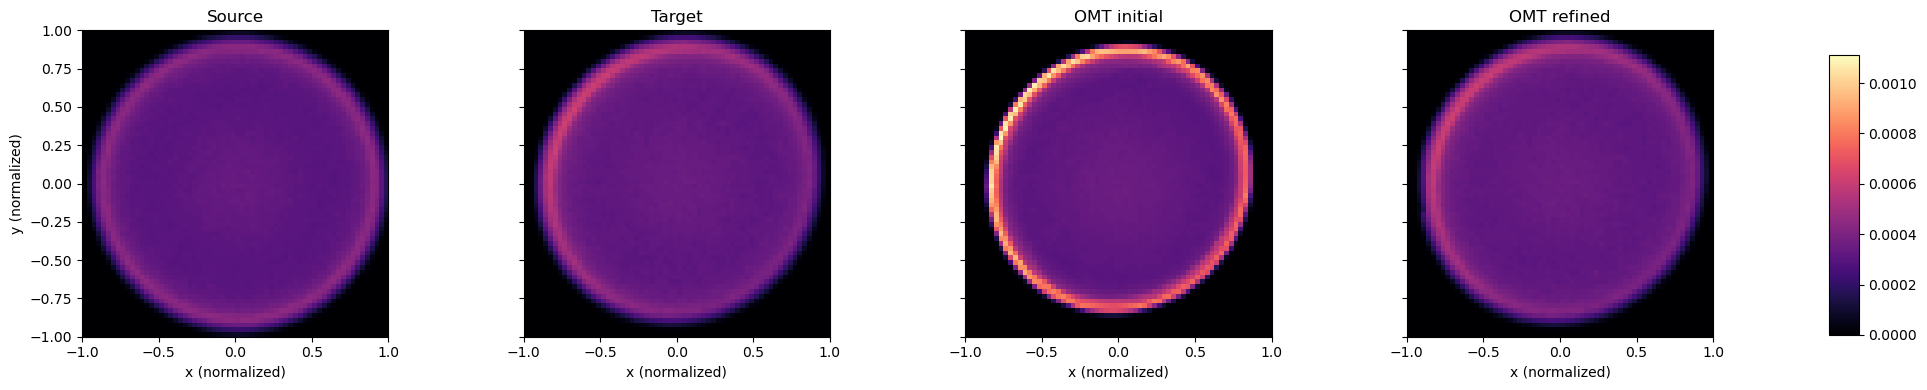

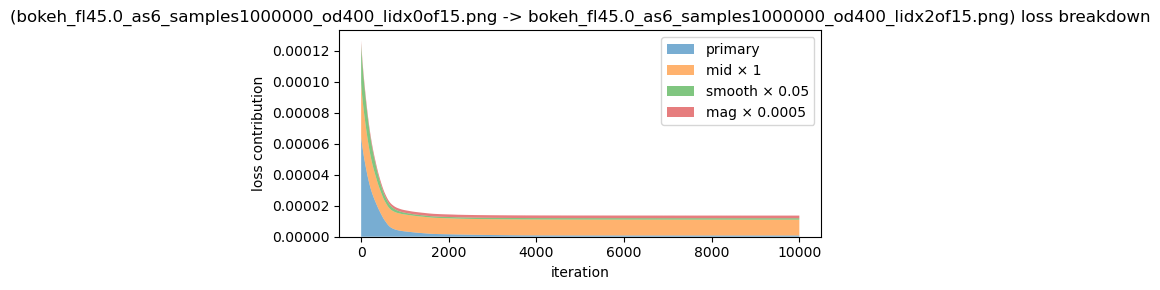

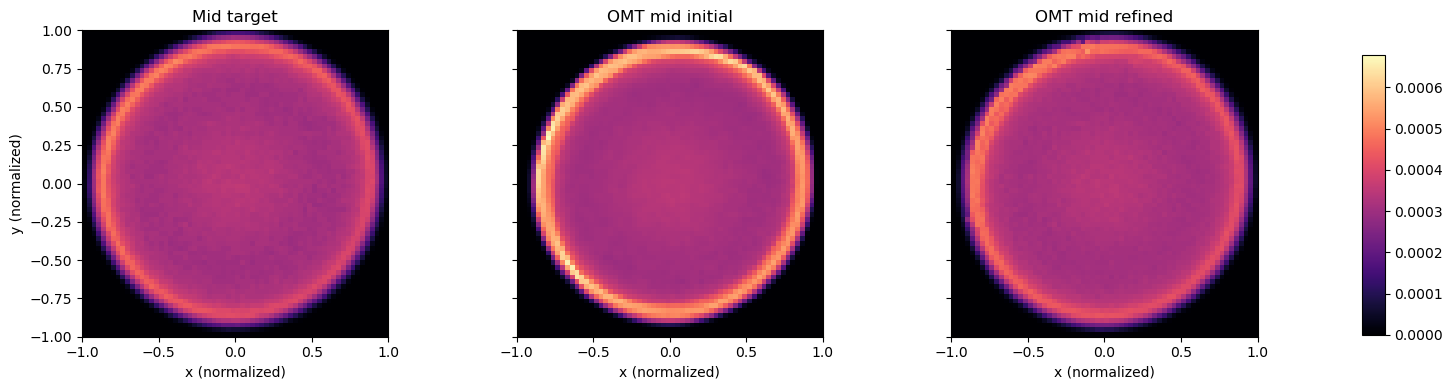

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\incremental\distortion_map_1.png

=== Distortion map 2 (from lidx 2 to 4) ===
Using device: cpu
iter 0001 total 0.000156 (primary 0.000071, mid 0.000031, smooth 0.001016, mag 0.005375)
iter 0500 total 0.000035 (primary 0.000013, mid 0.000009, smooth 0.000241, mag 0.003433)
iter 1000 total 0.000016 (primary 0.000002, mid 0.000009, smooth 0.000059, mag 0.003156)
iter 1500 total 0.000013 (primary 0.000001, mid 0.000009, smooth 0.000029, mag 0.003173)
iter 2000 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.000024, mag 0.003148)
iter 2500 total 0.000012 (primary 0.000000, mid 0.000009, smooth 0.000023, mag 0.003094)
iter 3000 total 0.000012 (primary 0.000000, mid 0.000009, smooth 0.000023, mag 0.003048)
iter 3500 total 0.000012 (primary 0.000000, mid 0.000009, smooth 0.000023, mag 0.003010)
iter 4000 total 0.000012 (primary 0.000000, mid 0.000009, smooth 0.000023, m

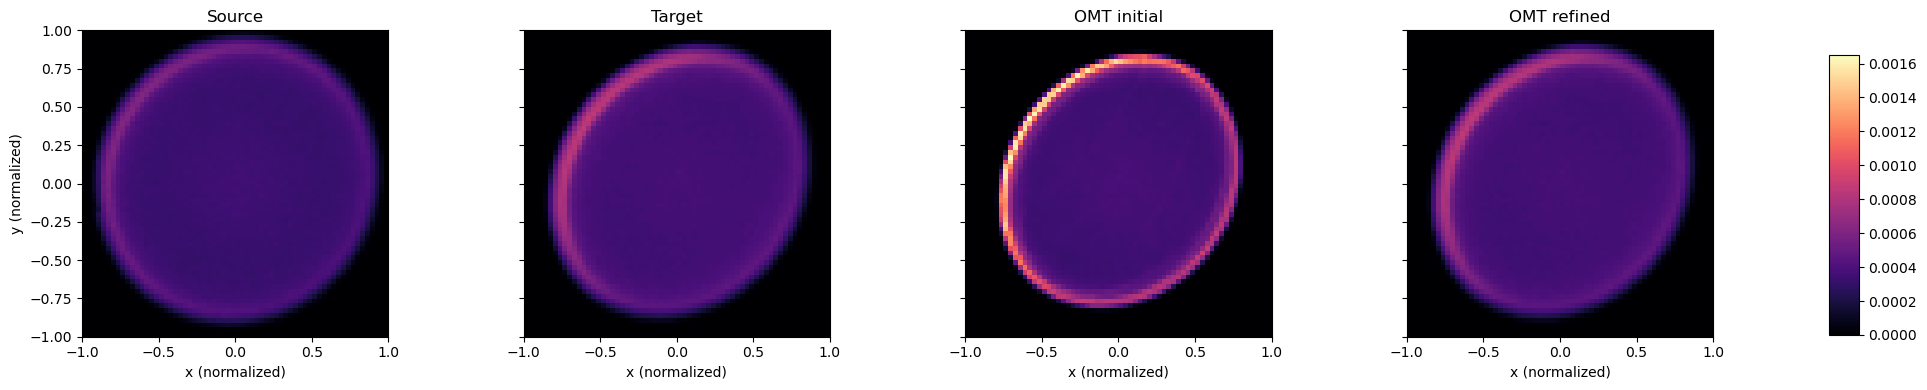

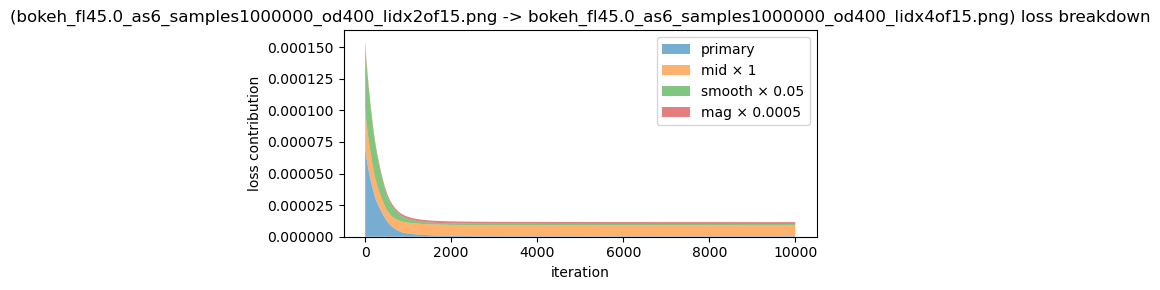

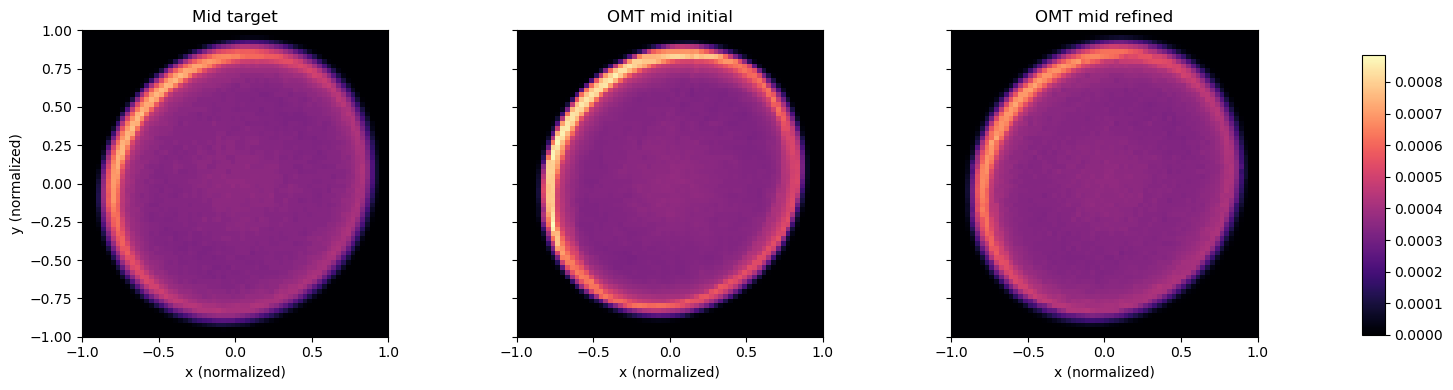

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\incremental\distortion_map_2.png

=== Distortion map 3 (from lidx 4 to 6) ===
Using device: cpu
iter 0001 total 0.000190 (primary 0.000082, mid 0.000035, smooth 0.001381, mag 0.007238)
iter 0500 total 0.000042 (primary 0.000013, mid 0.000007, smooth 0.000399, mag 0.004760)
iter 1000 total 0.000017 (primary 0.000003, mid 0.000007, smooth 0.000102, mag 0.004409)
iter 1500 total 0.000012 (primary 0.000001, mid 0.000007, smooth 0.000037, mag 0.004460)
iter 2000 total 0.000011 (primary 0.000001, mid 0.000007, smooth 0.000027, mag 0.004412)
iter 2500 total 0.000011 (primary 0.000000, mid 0.000007, smooth 0.000025, mag 0.004272)
iter 3000 total 0.000011 (primary 0.000000, mid 0.000007, smooth 0.000024, mag 0.004111)
iter 3500 total 0.000010 (primary 0.000000, mid 0.000007, smooth 0.000024, mag 0.003964)
iter 4000 total 0.000010 (primary 0.000000, mid 0.000007, smooth 0.000024, m

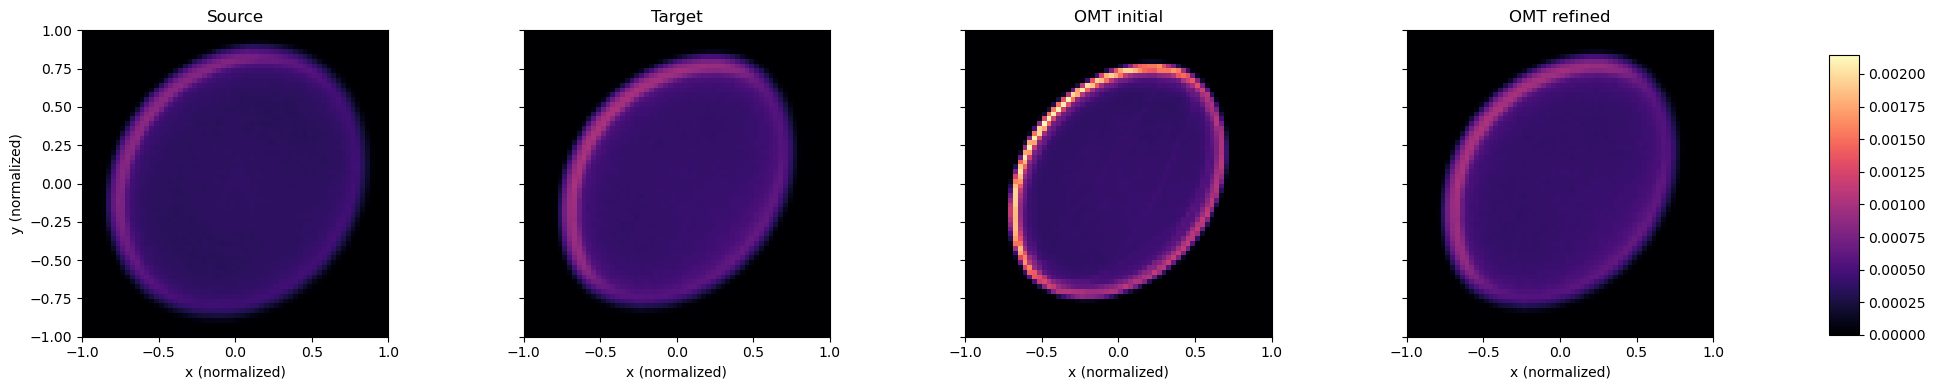

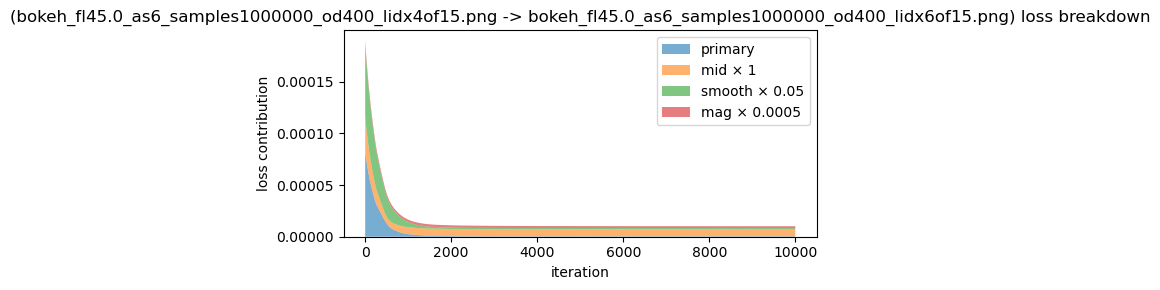

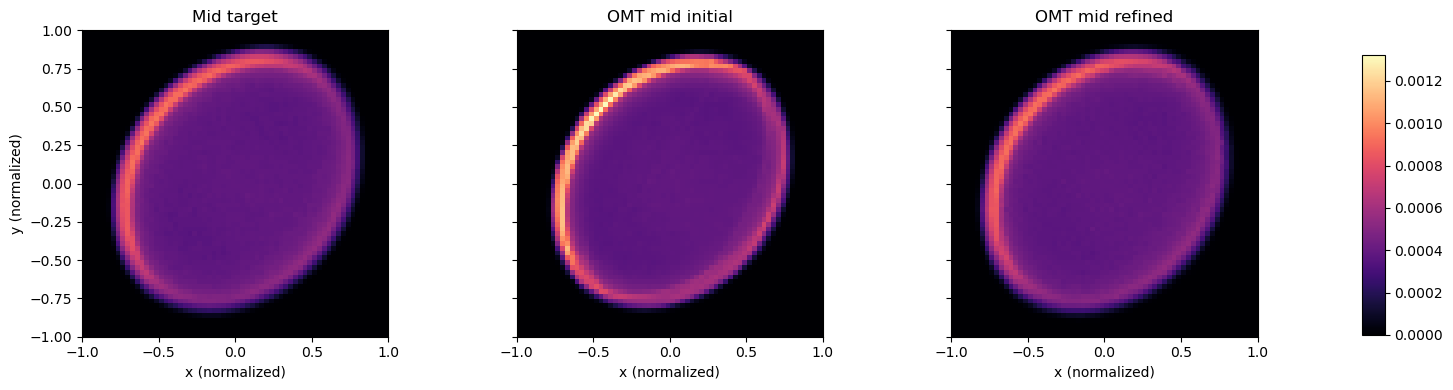

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\incremental\distortion_map_3.png

=== Distortion map 4 (from lidx 6 to 8) ===
Using device: cpu
iter 0001 total 0.000216 (primary 0.000095, mid 0.000040, smooth 0.001541, mag 0.008116)
iter 0500 total 0.000051 (primary 0.000017, mid 0.000007, smooth 0.000492, mag 0.005312)
iter 1000 total 0.000020 (primary 0.000004, mid 0.000007, smooth 0.000141, mag 0.004843)
iter 1500 total 0.000014 (primary 0.000002, mid 0.000007, smooth 0.000052, mag 0.004896)
iter 2000 total 0.000013 (primary 0.000001, mid 0.000007, smooth 0.000035, mag 0.004831)
iter 2500 total 0.000012 (primary 0.000001, mid 0.000007, smooth 0.000030, mag 0.004602)
iter 3000 total 0.000011 (primary 0.000001, mid 0.000007, smooth 0.000027, mag 0.004315)
iter 3500 total 0.000011 (primary 0.000001, mid 0.000007, smooth 0.000026, mag 0.004034)
iter 4000 total 0.000011 (primary 0.000001, mid 0.000007, smooth 0.000025, m

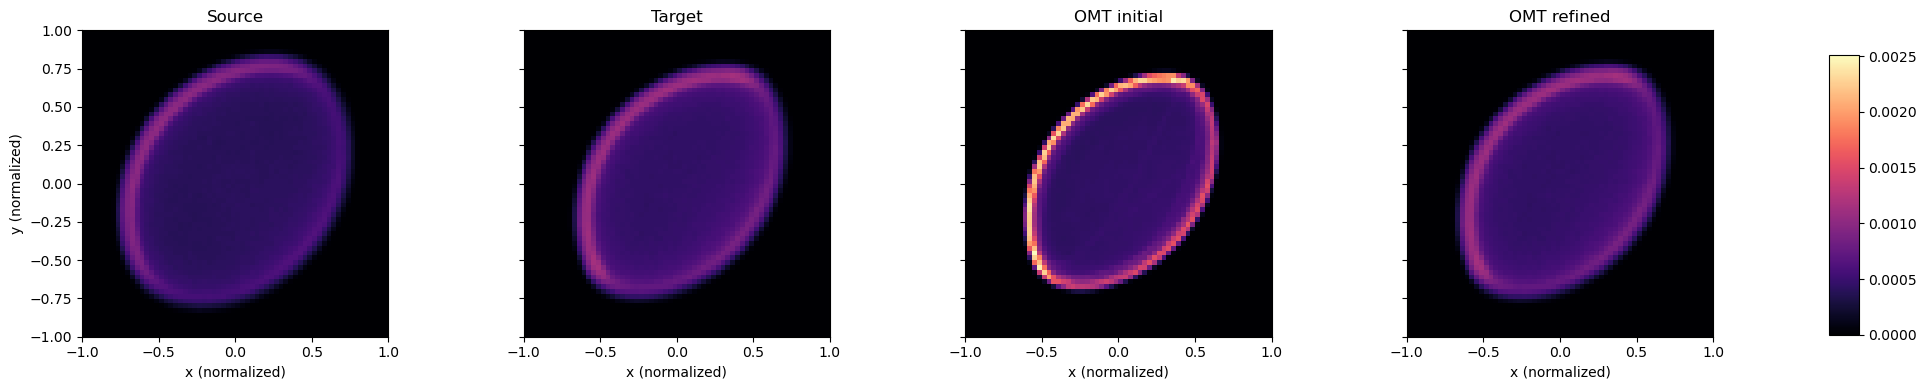

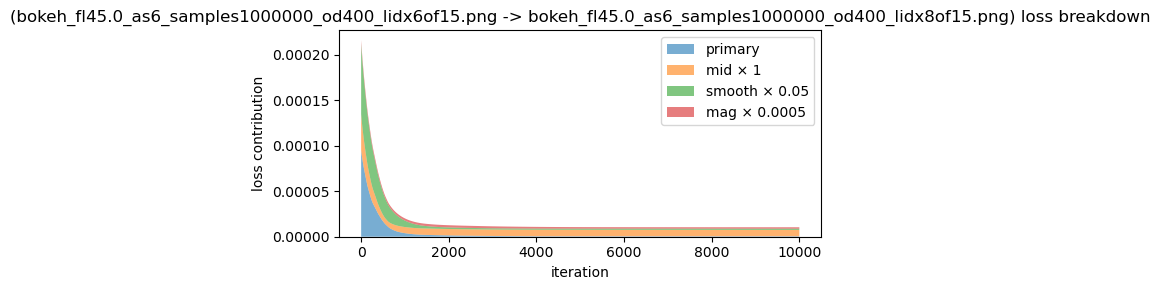

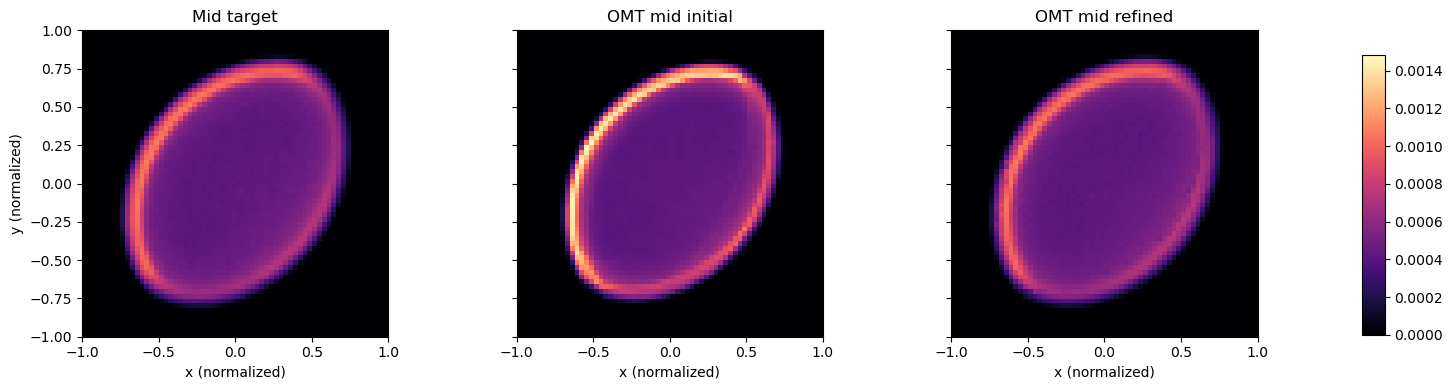

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\incremental\distortion_map_4.png

=== Distortion map 5 (from lidx 8 to 10) ===
Using device: cpu
iter 0001 total 0.000242 (primary 0.000106, mid 0.000046, smooth 0.001717, mag 0.008517)
iter 0500 total 0.000065 (primary 0.000020, mid 0.000012, smooth 0.000591, mag 0.005360)
iter 1000 total 0.000029 (primary 0.000006, mid 0.000011, smooth 0.000188, mag 0.004649)
iter 1500 total 0.000021 (primary 0.000003, mid 0.000012, smooth 0.000073, mag 0.004564)
iter 2000 total 0.000019 (primary 0.000002, mid 0.000012, smooth 0.000047, mag 0.004400)
iter 2500 total 0.000018 (primary 0.000001, mid 0.000012, smooth 0.000038, mag 0.004051)
iter 3000 total 0.000017 (primary 0.000001, mid 0.000012, smooth 0.000032, mag 0.003610)
iter 3500 total 0.000016 (primary 0.000001, mid 0.000012, smooth 0.000028, mag 0.003168)
iter 4000 total 0.000016 (primary 0.000001, mid 0.000013, smooth 0.000026, 

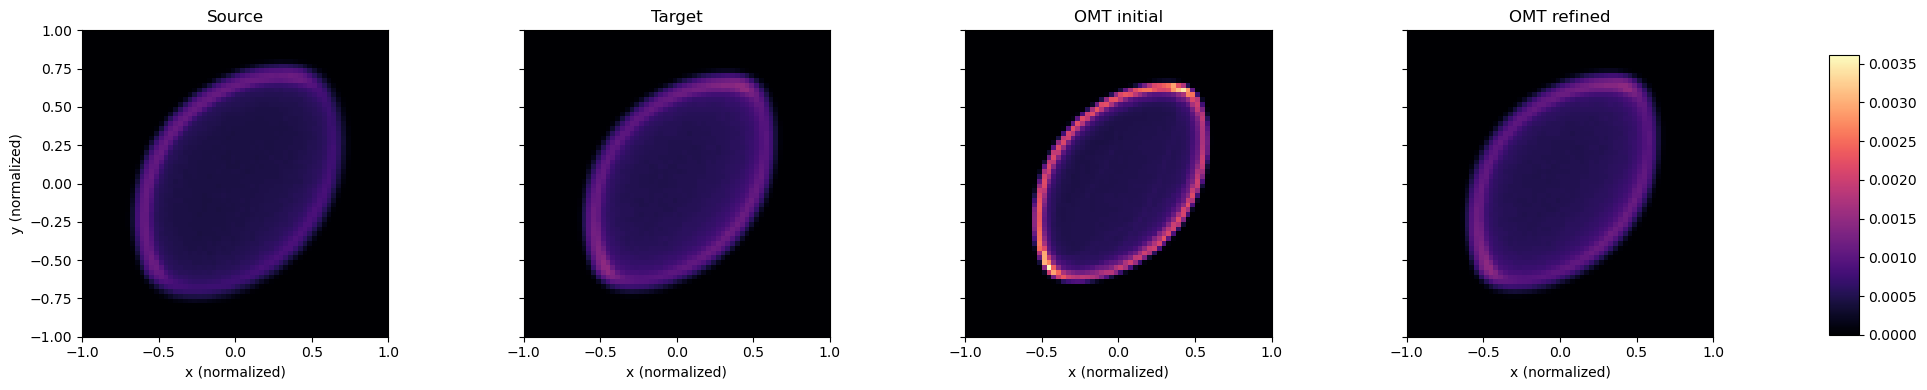

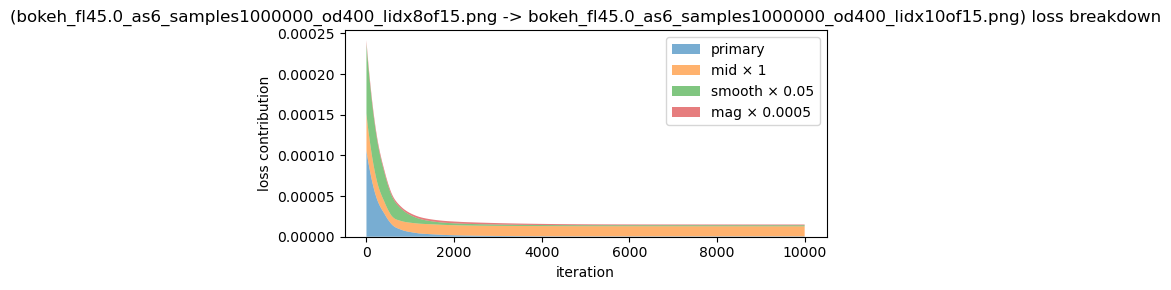

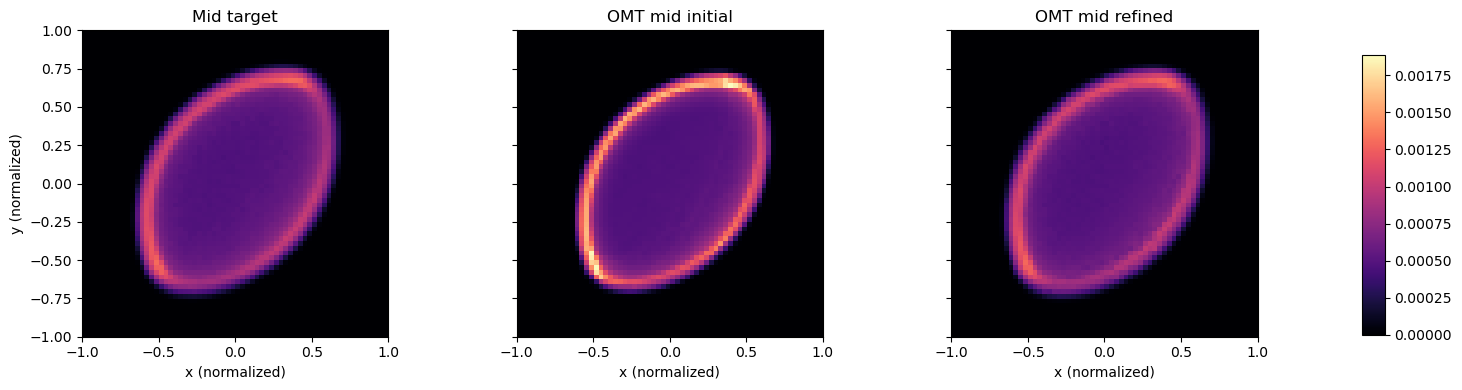

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\incremental\distortion_map_5.png

=== Distortion map 6 (from lidx 10 to 12) ===
Using device: cpu
iter 0001 total 0.000261 (primary 0.000116, mid 0.000049, smooth 0.001832, mag 0.009379)
iter 0500 total 0.000071 (primary 0.000024, mid 0.000010, smooth 0.000674, mag 0.005824)
iter 1000 total 0.000030 (primary 0.000010, mid 0.000006, smooth 0.000233, mag 0.004940)
iter 1500 total 0.000020 (primary 0.000006, mid 0.000007, smooth 0.000095, mag 0.004800)
iter 2000 total 0.000015 (primary 0.000002, mid 0.000007, smooth 0.000058, mag 0.004591)
iter 2500 total 0.000013 (primary 0.000001, mid 0.000008, smooth 0.000046, mag 0.004188)
iter 3000 total 0.000012 (primary 0.000001, mid 0.000008, smooth 0.000039, mag 0.003670)
iter 3500 total 0.000012 (primary 0.000001, mid 0.000008, smooth 0.000033, mag 0.003132)
iter 4000 total 0.000011 (primary 0.000001, mid 0.000008, smooth 0.000029,

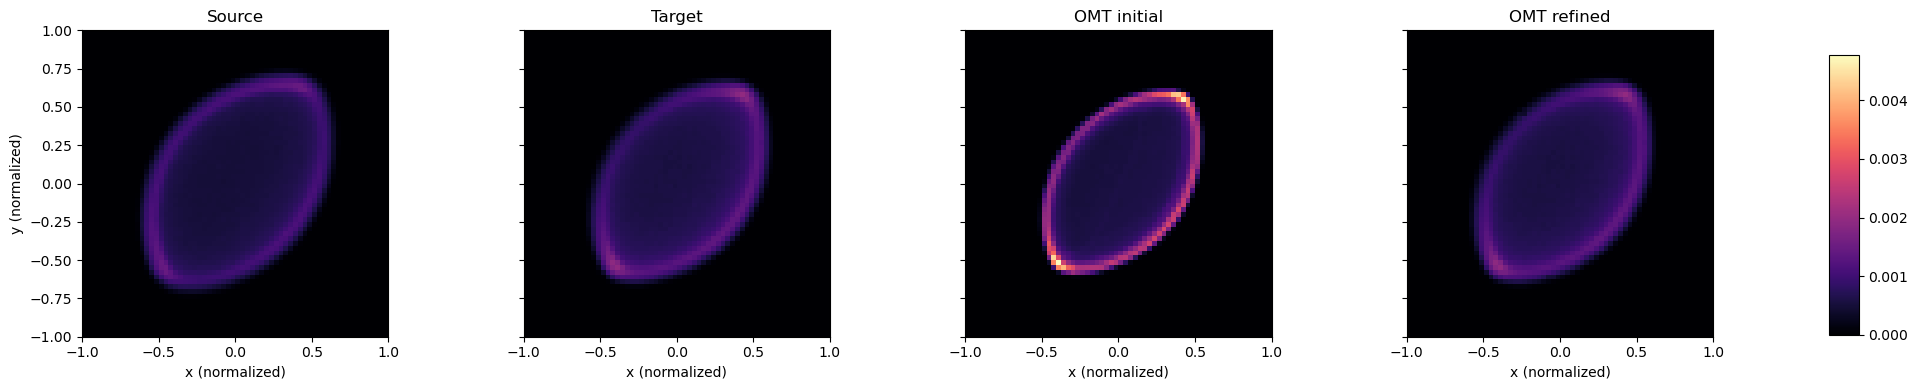

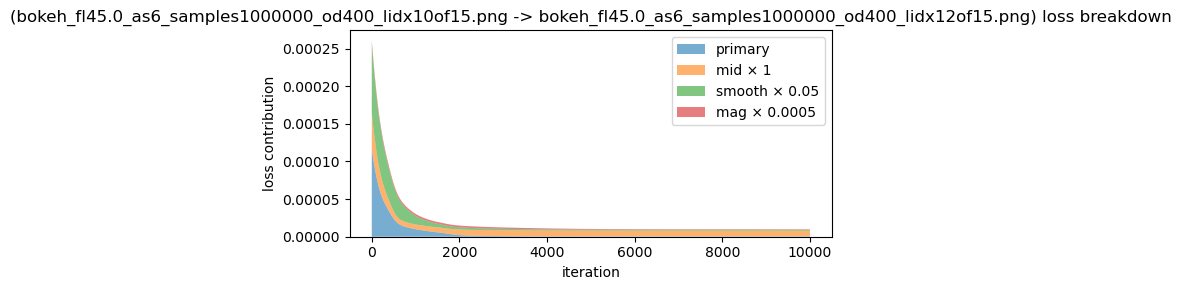

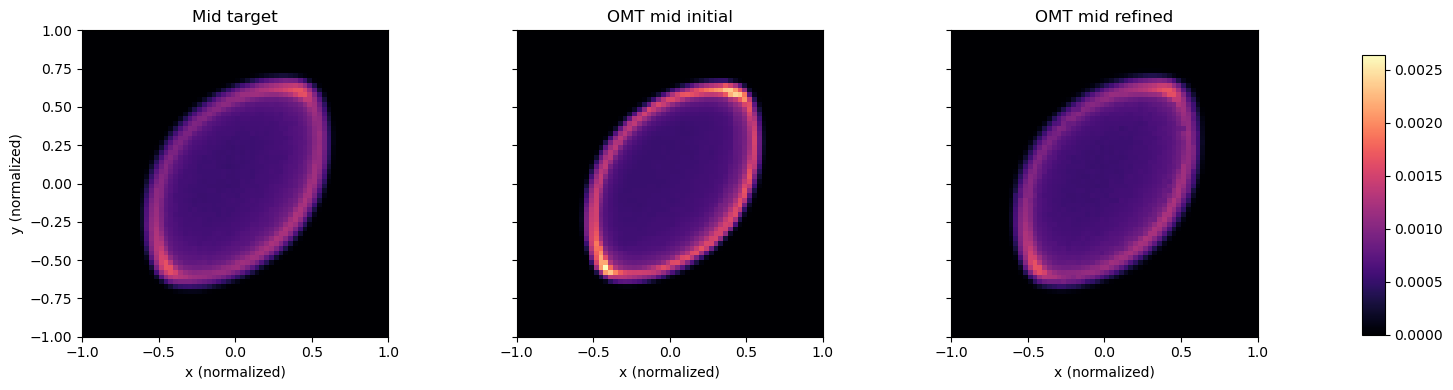

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\incremental\distortion_map_6.png


In [85]:
all_paths = {i: Path(f"C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/weights/bokeh_fl45.0_as6_samples1000000_od400_lidx{i}of15.png") for i in range(14)}

# Save identity map as distortion_map_0.png
height, width = desired_resolution
gy, gx = np.meshgrid(np.linspace(-1, 1, height), np.linspace(-1, 1, width), indexing="ij")
identity_coords = np.stack((gy, gx), axis=-1)
uint8_identity = ((np.stack((identity_coords[..., 1], identity_coords[..., 0]), axis=-1) + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
identity_rgb = np.zeros((height, width, 3), dtype=np.uint8)
identity_rgb[..., :2] = uint8_identity
Image.fromarray(identity_rgb, mode="RGB").save(output_folder / "distortion_map_0.png")
print(f"Saved identity distortion map to {output_folder / 'distortion_map_0.png'}")

refined_source = None
map_index = 1
for start_idx in range(0, 12, 2):
    end_idx = start_idx + 2
    print(f"\n=== Distortion map {map_index} (from lidx {start_idx} to {end_idx}) ===")
    refined_source = load_images_and_create_distortion_map(
        all_paths[start_idx], all_paths[end_idx], output_folder / "incremental" / f"distortion_map_{map_index}.png",
        resolution=desired_resolution, source_override=refined_source, midpoint_path=all_paths.get(start_idx + 1)
    )
    map_index += 1

In [86]:
# Load incremental
pattern = re.compile(r"^distortion_map_(\d+)\.png$")
distortion_maps = sorted(
    [p for p in (output_folder / "incremental").glob("distortion_map_*.png") if pattern.match(p.name)],
    key=lambda p: int(pattern.match(p.name).group(1))
)
print(f"Found {len(distortion_maps)} distortion maps: {[p.name for p in distortion_maps]}")

def load_displacement(path):
    dest = (np.asarray(Image.open(path), dtype=np.float32)[..., :2] / 127.5) - 1.0
    return np.stack((dest[..., 1] - source_coords_unit[..., 0], dest[..., 0] - source_coords_unit[..., 1]), axis=-1)

sequence_fields = [load_displacement(p) for p in distortion_maps]
field_height, field_width = sequence_fields[0].shape[:2]

def apply_field(points, field):
    pts = points.reshape(-1, 2)
    norm = np.clip((pts + 1.0) / 2.0, 0.0, 0.999999)
    disp = field[(norm[:, 0] * (field_height - 1)).astype(int), (norm[:, 1] * (field_width - 1)).astype(int)]
    return np.clip(pts + disp, -1.0, 1.0).reshape(points.shape)

Found 6 distortion maps: ['distortion_map_1.png', 'distortion_map_2.png', 'distortion_map_3.png', 'distortion_map_4.png', 'distortion_map_5.png', 'distortion_map_6.png']


In [87]:
parsed = [(int(m.group(1)), f) for p, f in zip(distortion_maps, sequence_fields) if (m := re.search(r"distortion_map_(\d+)\.png", p.name))]
parsed.sort()
print(f"Loaded {len(parsed)} distortion maps: {[p.name for p in distortion_maps]}")

running = np.zeros_like(parsed[0][1])
for idx, field in parsed:
    running = apply_field(source_coords_unit + running, field) - source_coords_unit

    dest = np.clip(source_coords_unit + running, -1.0, 1.0)
    uint8_data = ((np.stack((dest[..., 1], dest[..., 0]), axis=-1) + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    distortion_rgb = np.zeros((*running.shape[:2], 3), dtype=np.uint8)
    distortion_rgb[..., :2] = uint8_data
    out_path = output_folder / f"distortion_map_{idx}.png"
    Image.fromarray(distortion_rgb, mode="RGB").save(out_path)
    print(f"Saved cumulative distortion map 0 → {idx} to {out_path}")

Loaded 6 distortion maps: ['distortion_map_1.png', 'distortion_map_2.png', 'distortion_map_3.png', 'distortion_map_4.png', 'distortion_map_5.png', 'distortion_map_6.png']
Saved cumulative distortion map 0 → 1 to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_1.png
Saved cumulative distortion map 0 → 2 to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_2.png
Saved cumulative distortion map 0 → 3 to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_3.png
Saved cumulative distortion map 0 → 4 to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_4.png
Saved cumulative distortion map 0 → 5 to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_5.png
Saved cumulative distortion map 0 → 6 to C:\Users\ckobalt\D

# Visualize distortion maps

Found 6 incremental distortion maps


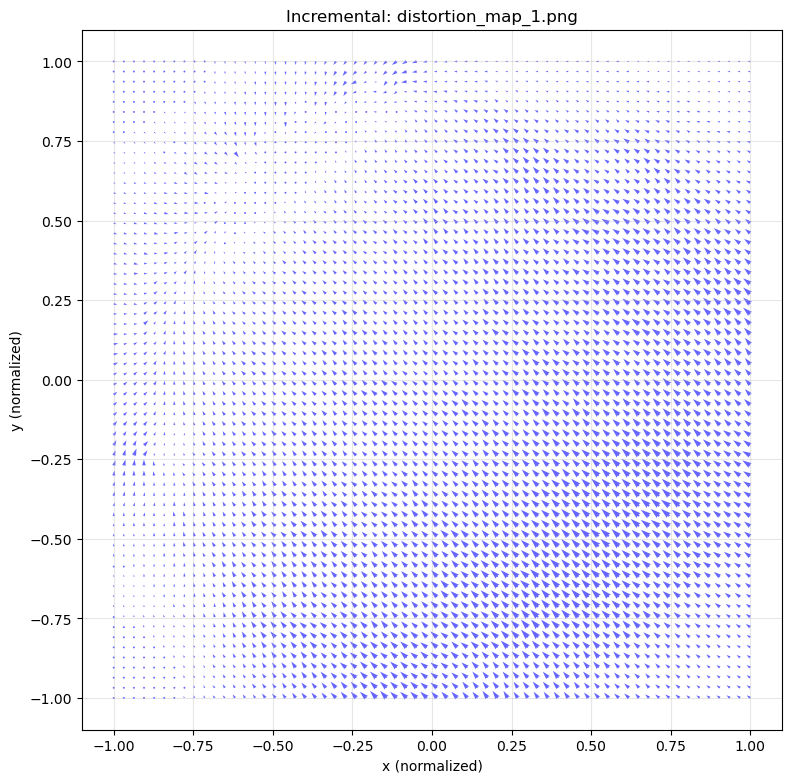

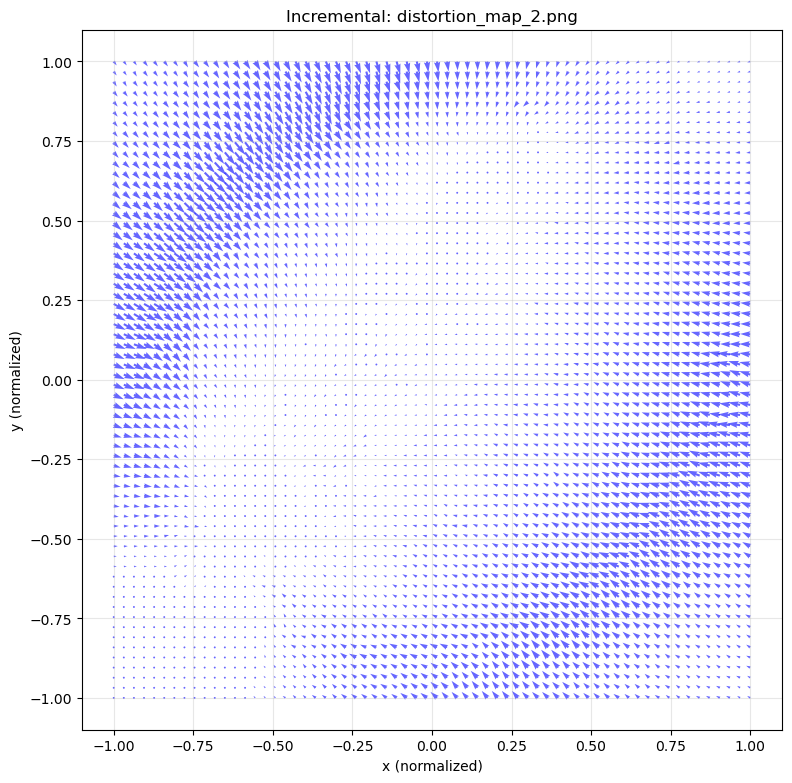

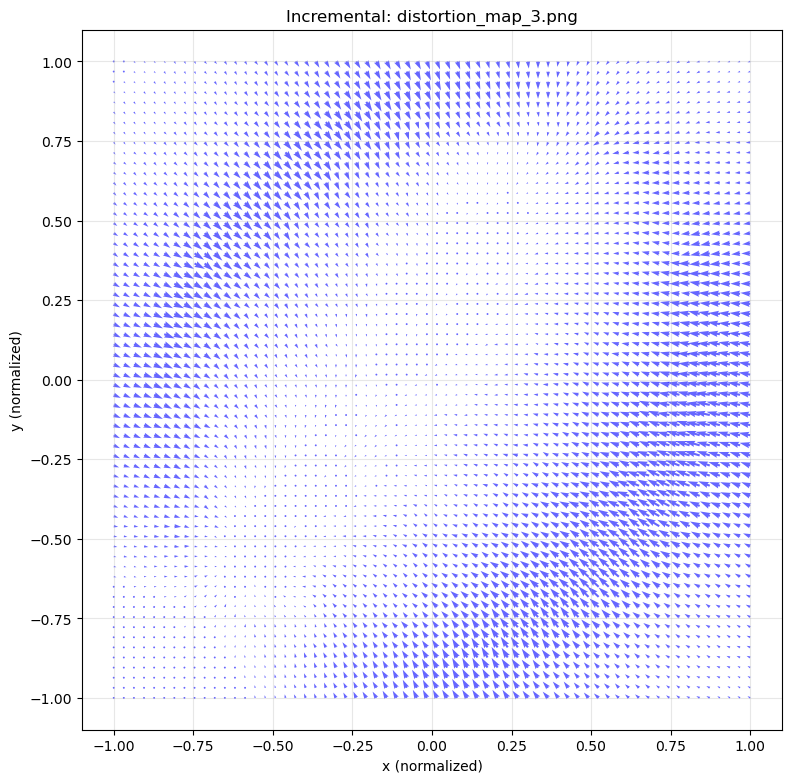

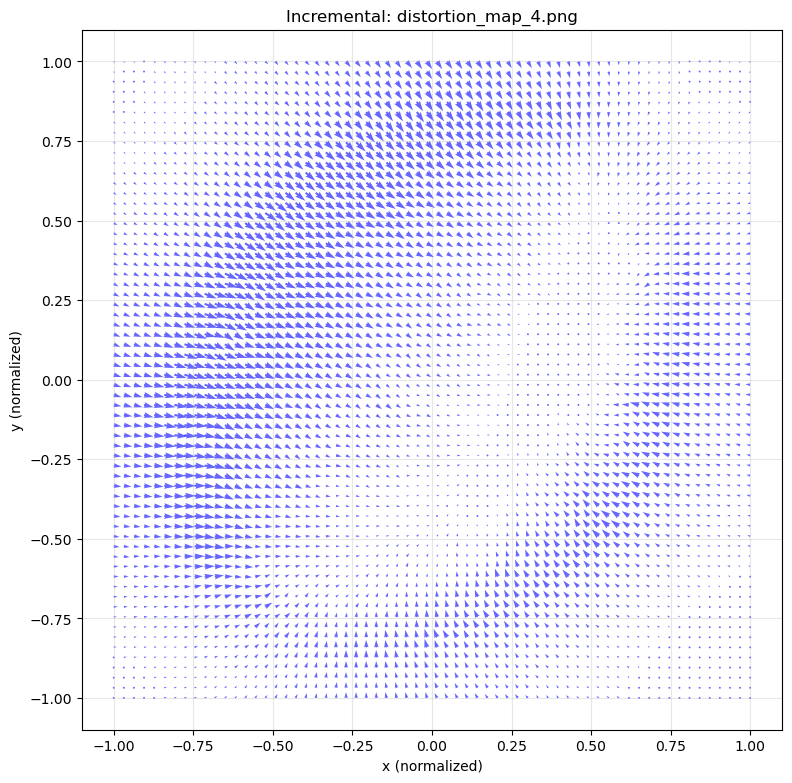

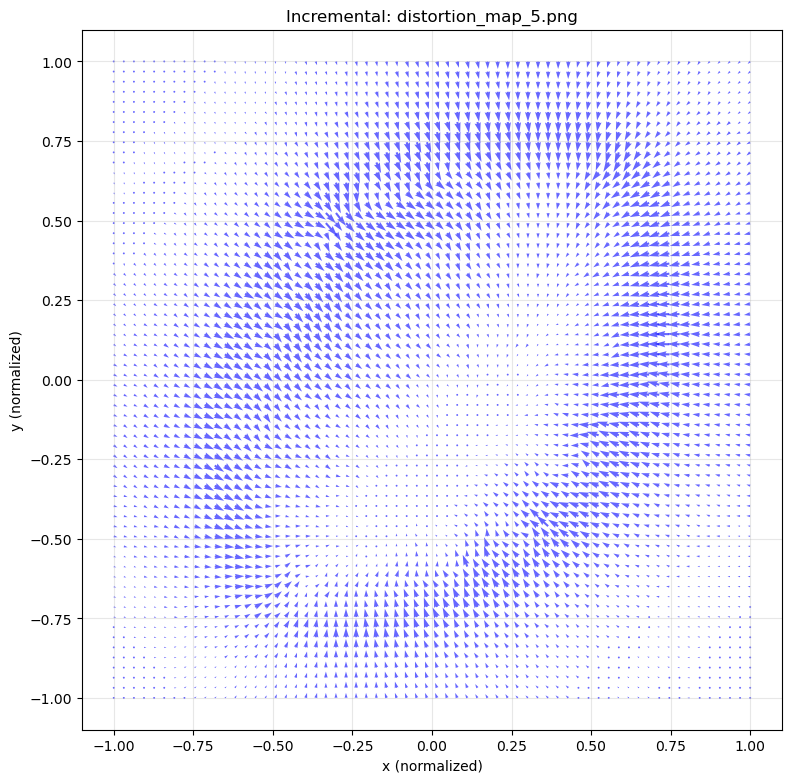

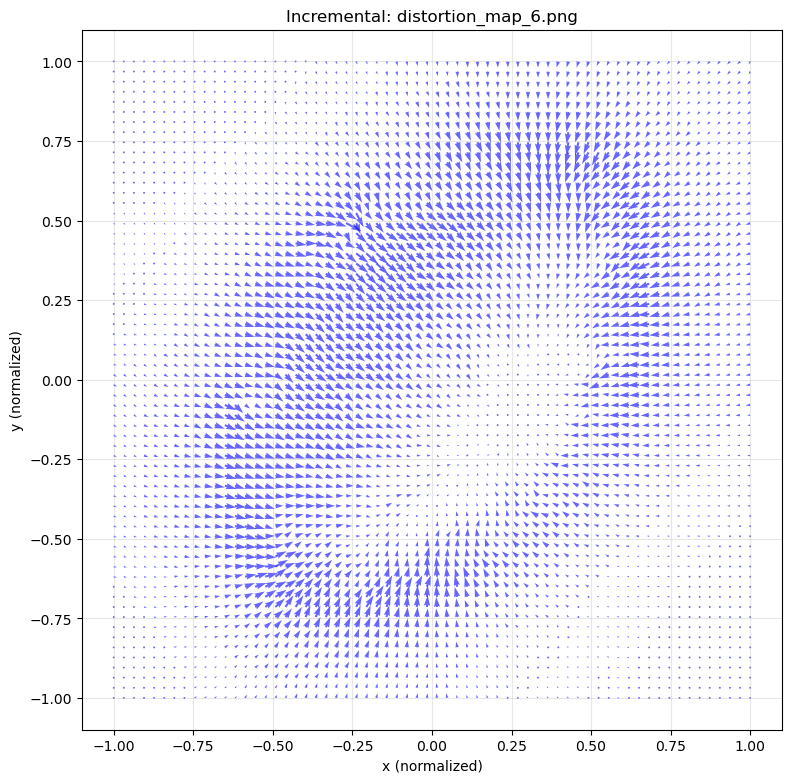


Found 7 cumulative distortion maps


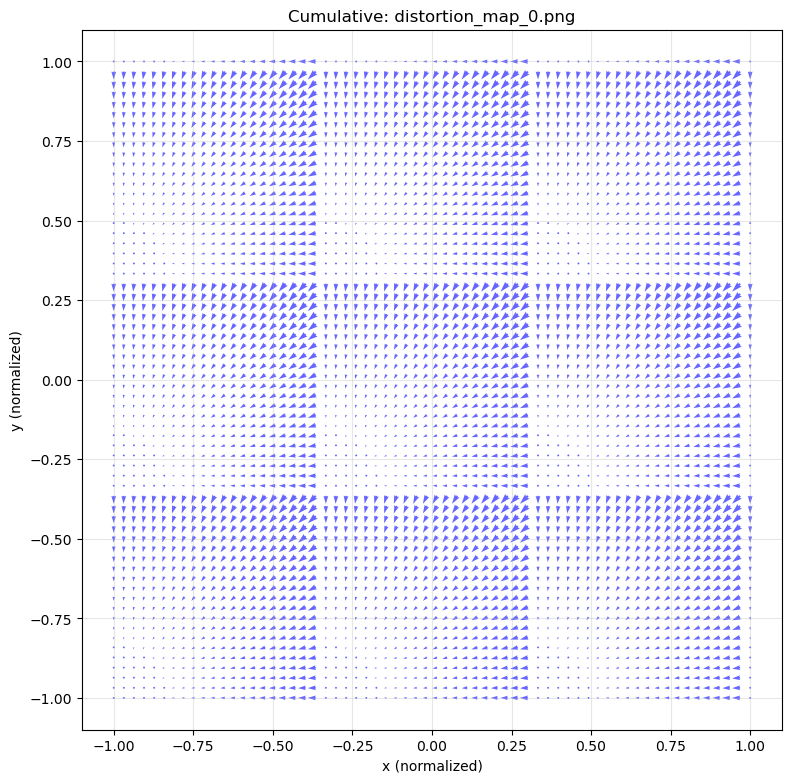

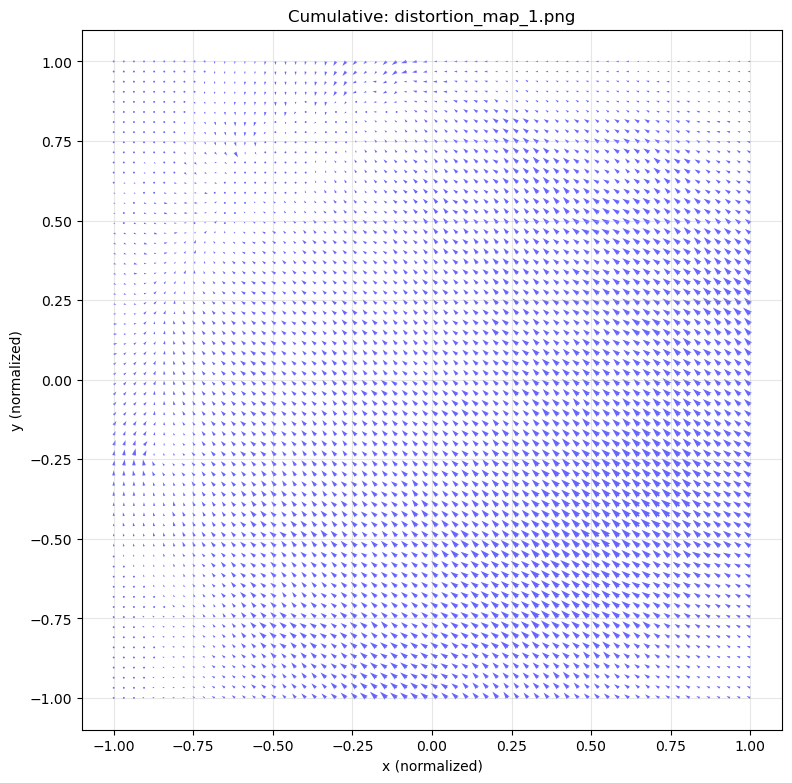

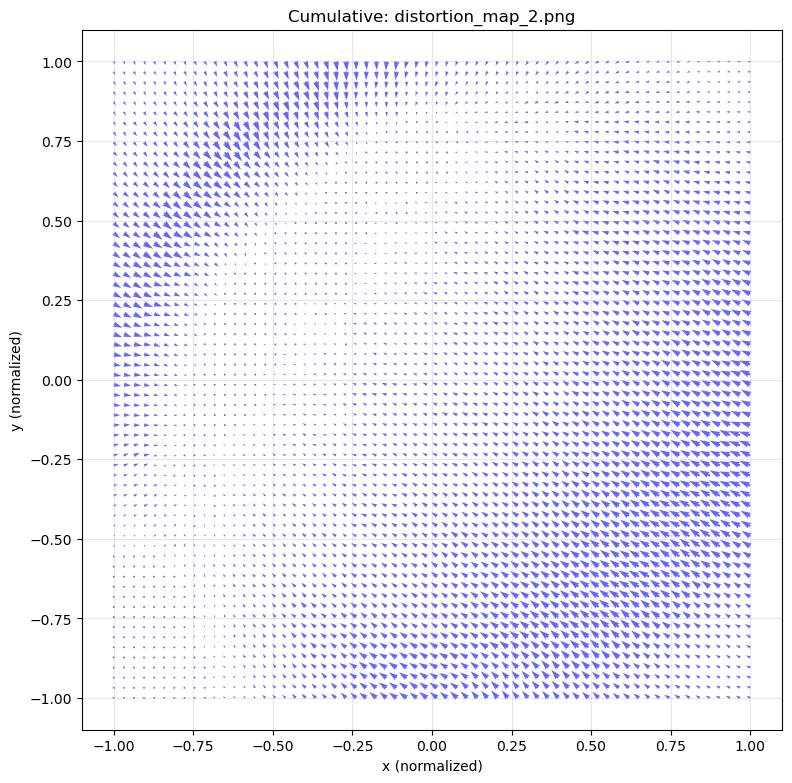

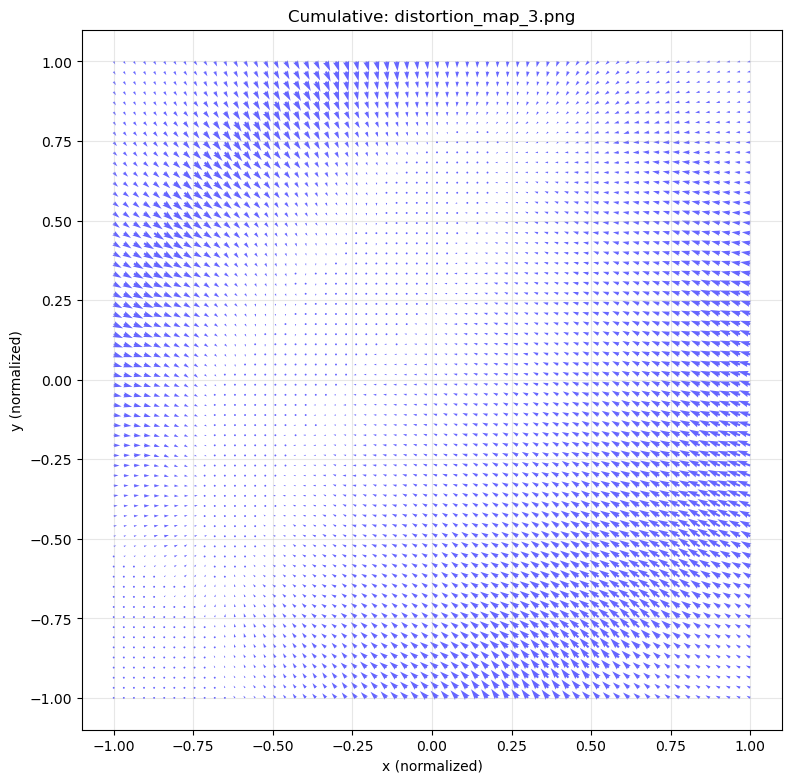

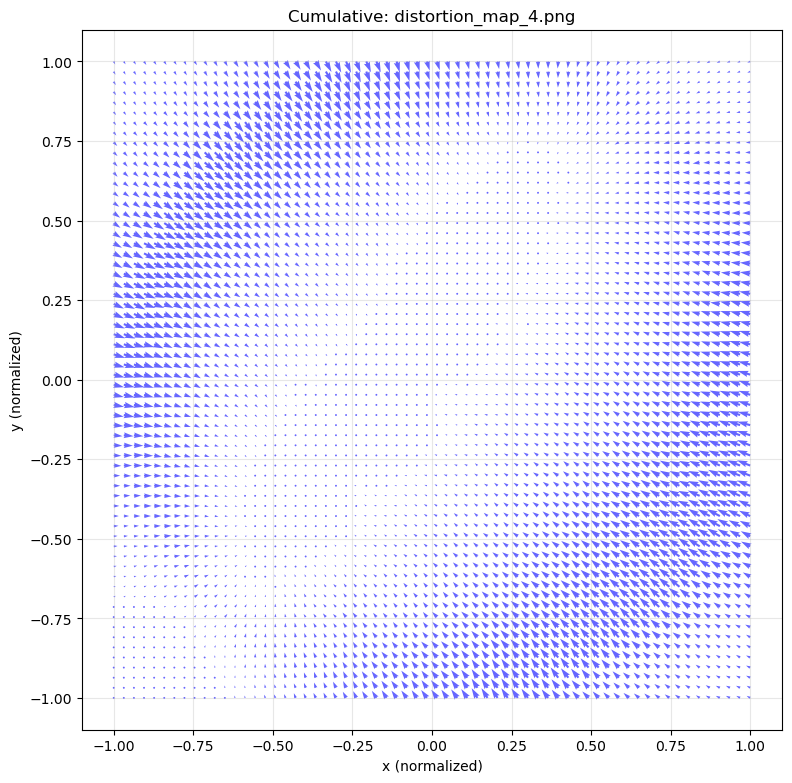

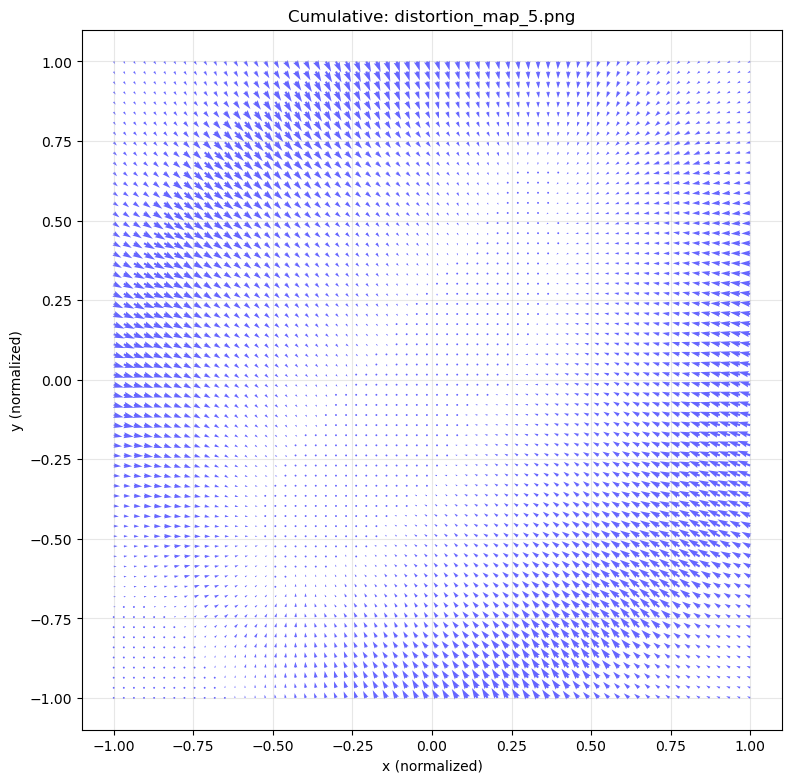

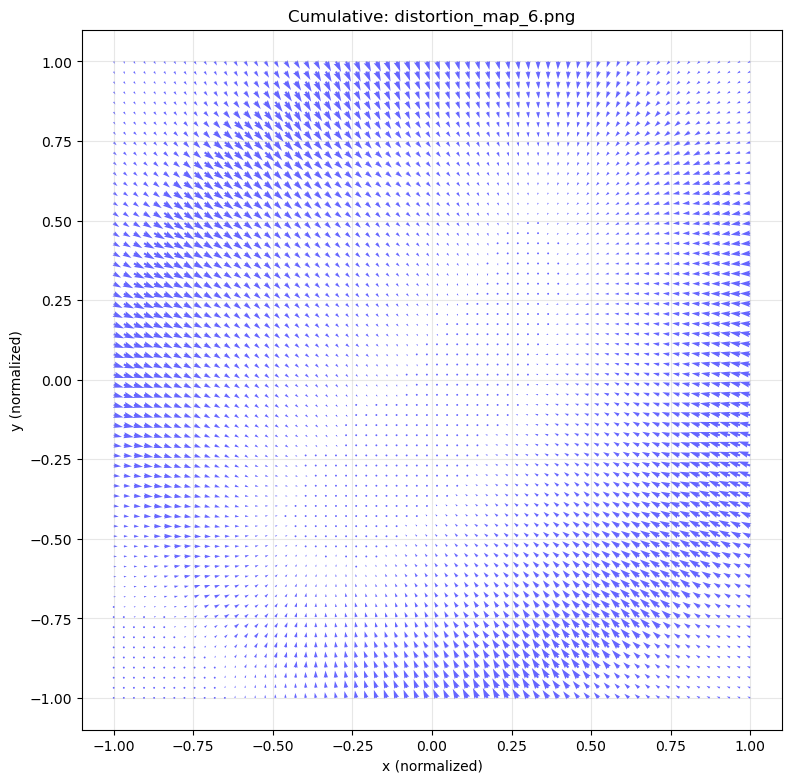

In [88]:
def plot_distortion_vectors(distortion_path: Path, *, title: str | None = None):
    dest = (np.asarray(Image.open(distortion_path), dtype=np.float32)[..., :2] / 127.5) - 1.0
    dest_coords = np.stack((dest[..., 1], dest[..., 0]), axis=-1)
    
    height, width = dest_coords.shape[:2]
    
    gy, gx = np.meshgrid(np.linspace(-1, 1, height), np.linspace(-1, 1, width), indexing="ij")
    source_coords = np.stack((gy, gx), axis=-1)
    
    displacement = dest_coords - source_coords
    
    Y = source_coords[:, :, 0]
    X = source_coords[:, :, 1]
    U = displacement[:, :, 1]
    V = displacement[:, :, 0]
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.quiver(X, Y, U, V, angles='xy', color='blue', alpha=0.6, width=0.003)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.set_xlabel('x (normalized)')
    ax.set_ylabel('y (normalized)')
    ax.set_title(title or distortion_path.name)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot all incremental distortion maps (distortion_map_i.png, excluding _from0)
incremental_maps = sorted(
    [p for p in (output_folder / "incremental").glob("distortion_map_*.png")],
    key=lambda p: int(re.search(r"distortion_map_(\d+)\.png", p.name).group(1))
)
print(f"Found {len(incremental_maps)} incremental distortion maps")
for map_path in incremental_maps:
    plot_distortion_vectors(map_path, title=f"Incremental: {map_path.name}")

# Plot all cumulative distortion maps (distortion_map_i_from0.png)
cumulative_maps = sorted(
    [p for p in output_folder.glob("distortion_map_*.png")],
    key=lambda p: int(re.search(r"distortion_map_(\d+)\.png", p.name).group(1))
)
print(f"\nFound {len(cumulative_maps)} cumulative distortion maps")
for map_path in cumulative_maps:
    plot_distortion_vectors(map_path, title=f"Cumulative: {map_path.name}")

# Apply distortion maps to noise

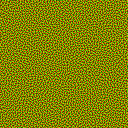

In [89]:
from PIL import Image

path = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\bokehConfig\\5_fast_noise\\bokeh_fl45.0_as6_samples500000_od500_lidx0of8_0.png"

noisemap_a = Image.open(path)
display(noisemap_a)

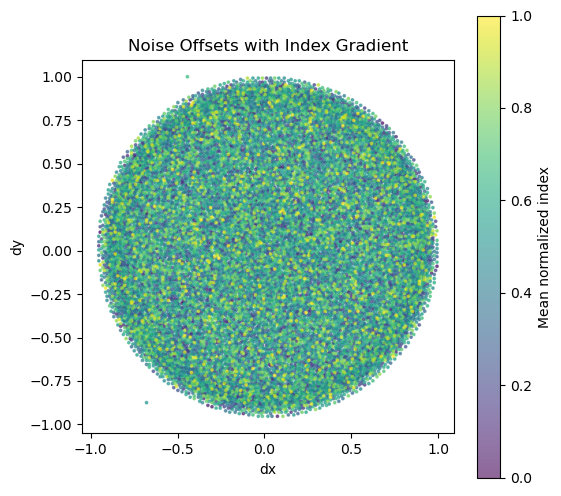

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from PIL import Image
from typing import Tuple

def normalize_offsets(image, *, center: float = 127.5) -> np.ndarray:
    offsets = np.asarray(image)[..., :2].astype(np.float32)
    return (offsets - center) / center

def scatter_index_colored(offsets: np.ndarray, *, cmap: str = "viridis", point_size: float = 3.0, alpha: float = 0.6):
    height, width, _ = offsets.shape
    dx = offsets[..., 0].ravel()
    dy = offsets[..., 1].ravel()

    total_span = max(height + width - 2, 1)
    rows, cols = np.indices((height, width), dtype=np.float32)
    colors = ((rows + cols) / total_span).ravel()

    fig, ax = plt.subplots(figsize=(6, 6))
    scatter = ax.scatter(dx, dy, c=colors, cmap=cmap, s=point_size, alpha=alpha)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("dx")
    ax.set_ylabel("dy")
    ax.set_title("Noise Offsets with Index Gradient")
    fig.colorbar(scatter, ax=ax, label="Mean normalized index")
    return fig, ax

def sort_offsets_by_target(offsets: np.ndarray, target: Tuple[float, float] = (1.0, 1.0)) -> np.ndarray:
    height, width, _ = offsets.shape
    flat = offsets.reshape(-1, 2)
    target_vec = np.asarray(target, dtype=np.float32)

    distance_order = np.argsort(np.linalg.norm(flat - target_vec, axis=1))

    rows, cols = np.indices((height, width))
    rows = rows.ravel()
    cols = cols.ravel()
    position_order = np.lexsort((cols, rows + cols))

    reordered = np.empty_like(flat)
    reordered[position_order] = flat[distance_order]
    return reordered.reshape(height, width, 2)

def offsets_to_image(offsets: np.ndarray):
    uint8_data = ((offsets + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    rgb = np.zeros((*offsets.shape[:2], 3), dtype=np.uint8)
    rgb[..., :2] = uint8_data
    return Image.fromarray(rgb, mode="RGB")

offsets_a = normalize_offsets(noisemap_a)
scatter_index_colored(offsets_a)
plt.show()

In [93]:
from scipy.ndimage import map_coordinates

def apply_distortion_to_offsets(offsets: np.ndarray, distortion_field: np.ndarray, *, use_bilinear: bool = True) -> np.ndarray:
    height, width, _ = offsets.shape
    field_height, field_width = distortion_field.shape[:2]
    
    flat_offsets = offsets.reshape(-1, 2)
    
    # Map offsets from [-1, 1] to field pixel coordinates [0, field_size-1]
    norm = np.clip((flat_offsets + 1.0) / 2.0, 0.0, 1.0)
    field_y = norm[:, 0] * (field_height - 1)
    field_x = norm[:, 1] * (field_width - 1)
    
    if use_bilinear:
        # Bilinear interpolation using scipy
        coords = np.stack([field_y, field_x], axis=0)
        disp_y = map_coordinates(distortion_field[..., 0], coords, order=1, mode='nearest') # mode is boundary behavior
        disp_x = map_coordinates(distortion_field[..., 1], coords, order=1, mode='nearest')
        displacement = np.stack([disp_y, disp_x], axis=-1)
    else:
        # Nearest-neighbor
        fy = np.clip(field_y.astype(int), 0, field_height - 1)
        fx = np.clip(field_x.astype(int), 0, field_width - 1)
        displacement = distortion_field[fy, fx]
    
    distorted = flat_offsets + displacement
    distorted = np.clip(distorted, -1.0, 1.0)
    
    return distorted.reshape(height, width, 2)

def interactive_incremental_distortion(offsets: np.ndarray):
    incremental_maps = sorted(
        [p for p in (output_folder / "incremental").glob("distortion_map_*.png")],
        key=lambda p: int(re.search(r"distortion_map_(\d+)\.png", p.name).group(1))
    )
    
    fields = []
    for map_path in incremental_maps:
        dest = (np.asarray(Image.open(map_path), dtype=np.float32)[..., :2] / 127.5) - 1.0
        dest_coords = np.stack((dest[..., 1], dest[..., 0]), axis=-1)
        
        height, width = dest_coords.shape[:2]
        gy, gx = np.meshgrid(np.linspace(-1, 1, height), np.linspace(-1, 1, width), indexing="ij")
        source_coords = np.stack((gy, gx), axis=-1)
        displacement = dest_coords - source_coords
        fields.append(displacement)
    
    def update(step_idx, use_bilinear):
        if step_idx == 0:
            distorted = offsets
            title = "Original (no distortion)"
        else:
            distorted = offsets.copy()
            for i in range(step_idx):
                distorted = apply_distortion_to_offsets(distorted, fields[i], use_bilinear=use_bilinear)
            title = f"Incremental step {step_idx}/{len(fields)}"
        
        fig, ax = scatter_index_colored(distorted, point_size=3.0, alpha=0.6)
        ax.set_title(title + (" (bilinear)" if use_bilinear else " (nearest)"))
        plt.show()
    
    step_slider = widgets.IntSlider(value=0, min=0, max=len(fields), step=1, description='Step:', continuous_update=False)
    bilinear_toggle = widgets.Checkbox(value=True, description='Bilinear interp')
    
    widgets.interact(update, step_idx=step_slider, use_bilinear=bilinear_toggle)

def interactive_cumulative_distortion(offsets: np.ndarray):
    cumulative_maps = sorted(
        [p for p in output_folder.glob("distortion_map_*.png")],
        key=lambda p: int(re.search(r"distortion_map_(\d+)\.png", p.name).group(1))
    )
    
    if not cumulative_maps:
        print("No cumulative distortion maps found!")
        return
    
    fields = []
    for map_path in cumulative_maps:
        dest = (np.asarray(Image.open(map_path), dtype=np.float32)[..., :2] / 127.5) - 1.0
        dest_coords = np.stack((dest[..., 1], dest[..., 0]), axis=-1)
        
        height, width = dest_coords.shape[:2]
        gy, gx = np.meshgrid(np.linspace(-1, 1, height), np.linspace(-1, 1, width), indexing="ij")
        source_coords = np.stack((gy, gx), axis=-1)
        displacement = dest_coords - source_coords
        fields.append((map_path.name, displacement))
    
    def update(step_idx, use_bilinear):
        if step_idx == 0:
            distorted = offsets
            title = "Original (no distortion)"
        else:
            map_name, field = fields[step_idx - 1]
            distorted = apply_distortion_to_offsets(offsets, field, use_bilinear=use_bilinear)
            title = f"Cumulative: {map_name}"
        
        fig, ax = scatter_index_colored(distorted, point_size=3.0, alpha=0.6)
        ax.set_title(title + (" (bilinear)" if use_bilinear else " (nearest)"))
        plt.show()
    
    step_slider = widgets.IntSlider(value=0, min=0, max=len(fields), step=1, description='Step:', continuous_update=False)
    bilinear_toggle = widgets.Checkbox(value=True, description='Bilinear interp')
    
    widgets.interact(update, step_idx=step_slider, use_bilinear=bilinear_toggle)

# Create the interactive visualizations
print("=== Interactive Incremental Distortion ===")
print("(This is the correct approach for arbitrary offsets)")
interactive_incremental_distortion(offsets_a)

print("\n=== Interactive Cumulative Distortion ===")
print("(Shows pre-computed grid trajectories - differs for off-grid points)")
interactive_cumulative_distortion(offsets_a)

=== Interactive Incremental Distortion ===
(This is the correct approach for arbitrary offsets)


interactive(children=(IntSlider(value=0, continuous_update=False, description='Step:', max=6), Checkbox(value=…


=== Interactive Cumulative Distortion ===
(Shows pre-computed grid trajectories - differs for off-grid points)


interactive(children=(IntSlider(value=0, continuous_update=False, description='Step:', max=7), Checkbox(value=…